In this notebook we are following the chapter 12 of Time Series Forecasting In Python by Marco Peix

In [2]:
import pandas as pd

df = pd.read_csv('./data/metro_interstate_traffic_volume_preprocessed.csv')

df.head()

,date_time,temp,rain_1h,snow_1h,clouds_all,traffic_volume
0,2016-09-29 17:00:00,291.75,0.0,0,0,5551.0
1,2016-09-29 18:00:00,290.36,0.0,0,0,4132.0
2,2016-09-29 19:00:00,287.86,0.0,0,0,3435.0
3,2016-09-29 20:00:00,285.91,0.0,0,0,2765.0
4,2016-09-29 21:00:00,284.31,0.0,0,0,2443.0


In [3]:
df.shape

(17551, 6)

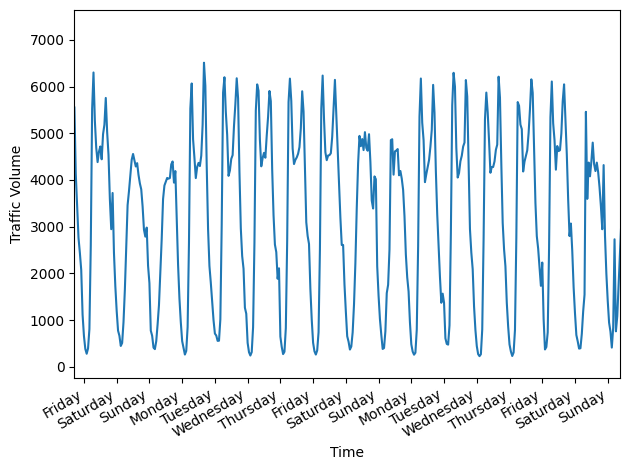

In [4]:
import matplotlib.pyplot as plt
import numpy as np


fig,ax = plt.subplots()

ax.plot(df['traffic_volume'])
ax.set_xlabel('Time')
ax.set_ylabel('Traffic Volume')

plt.xticks(np.arange(7,400,24),['Friday', 'Saturday', 'Sunday',
                                'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
                                'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.xlim(0,400)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

Plotting the Temp variation over time

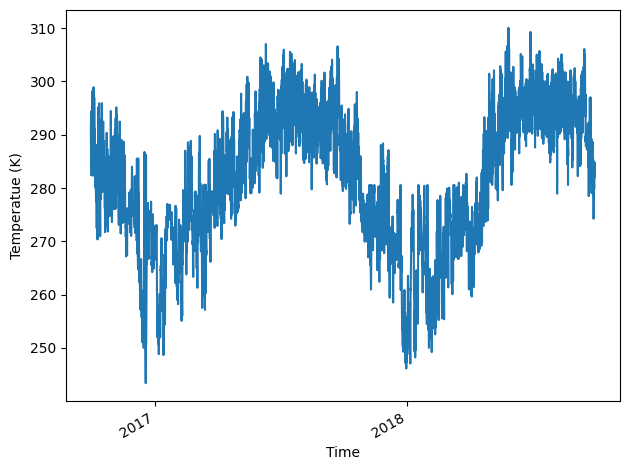

In [5]:
fig, ax = plt.subplots()

ax.plot(df['temp'])
ax.set_xlabel('Time')
ax.set_ylabel('Temperatue (K)')

plt.xticks([2239,10999],[2017,2018])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

We can see temp has seasonality over year. Lets see if temp has seasonality over the period of day.

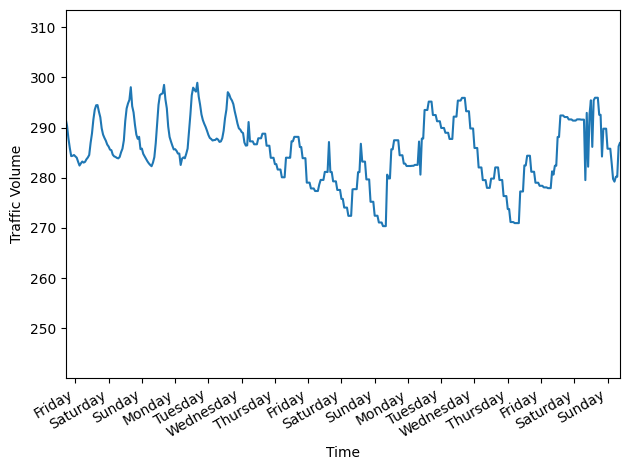

In [6]:
fig,ax = plt.subplots()

ax.plot(df['temp'])
ax.set_xlabel('Time')
ax.set_ylabel('Traffic Volume')

plt.xticks(np.arange(7,400,24),['Friday', 'Saturday', 'Sunday',
                                'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
                                'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.xlim(0,400)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
temp,17551.0,281.416203,12.688262,243.39,272.22,282.41,291.89,310.07
rain_1h,17551.0,0.025523,0.259794,0.00,0.00,0.00,0.00,10.60
snow_1h,17551.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
clouds_all,17551.0,42.034129,39.065960,0.00,1.00,40.00,90.00,100.00
traffic_volume,17551.0,3321.484588,1969.223949,113.00,1298.00,3518.00,4943.00,7280.00


looking at this we can see that rain is almost zero and snow is literally zero throughout the dataset. So we will drop those 2 features as they are not strong predictors for variation of traffic volume over time.

In [8]:
df = df.drop(['rain_1h','snow_1h'], axis=1)

We need to encode time stamp to a value which can be used by our models. So we will convert it to a numerical value by expressing data as a number of seconds. 

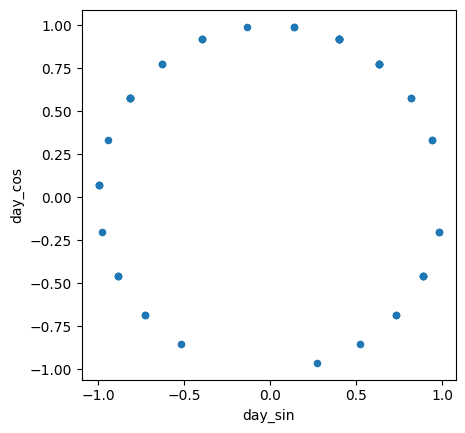

In [9]:
import datetime

timestamp_s = pd.to_datetime(df['date_time']).map(datetime.datetime.timestamp)

day = 23*60*60

df['day_sin'] = (np.sin(timestamp_s * (2*np.pi/day))).values    # maintaining cyclic nature
df['day_cos'] = (np.cos(timestamp_s * (2*np.pi/day))).values    

df = df.drop(['date_time'], axis=1)

df.sample(50).plot.scatter('day_sin','day_cos').set_aspect('equal')

In [10]:
n = len(df)

train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7): int(n*0.9)]
test_df = df[int(n*0.9):]


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train_df)

train_df[train_df.columns] = scaler.transform(train_df[train_df.columns])
val_df[val_df.columns] = scaler.transform(val_df[val_df.columns])
test_df[test_df.columns] = scaler.transform(test_df[test_df.columns])

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_14812\2663594738.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[train_df.columns] = scaler.transform(train_df[train_df.columns])
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_14812\2663594738.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[val_df.columns] = scaler.transform(val_df[val_df.columns])
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_14812\2663594738.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [ ]:
train_df.to_csv